In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")


In [2]:
df_time = pd.read_csv("delivery_dataset_enhanced.csv")

In [3]:
df_time.head(30000)

,city,area_of_interest_type,distance_km,hour_of_day,day_of_week,is_weekend,delivery_duration_minutes,accept_hour,accept_day_of_week,accept_month,No_of_orders,traffic,weather_condition,traffic_encoded,num_delivery_partners,population_density
0,Houston,Industrial,16.45,2.0,Thursday,1.0,19.0,5.0,Saturday,12.0,272,Medium,Sunny,1,9,20000
1,San Francisco,Industrial,2.63,2.0,Saturday,0.0,6.0,11.0,Friday,11.0,210,Medium,Rain,1,14,40000
2,Chicago,Industrial,16.77,19.0,Wednesday,1.0,10.0,8.0,Thursday,7.0,404,High,Rain,2,5,40000
3,San Francisco,Industrial,12.71,4.0,Wednesday,0.0,17.0,10.0,Wednesday,8.0,167,Medium,Overcast,1,8,30000
4,San Francisco,Downtown,10.46,2.0,Tuesday,0.0,8.0,14.0,Wednesday,7.0,223,Medium,Rain,1,6,20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,New York,Downtown,14.05,9.0,Thursday,0.0,16.0,19.0,Thursday,3.0,487,High,Rain,2,14,10000
29996,Los Angeles,Downtown,17.71,0.0,Saturday,1.0,9.0,9.0,Sunday,1.0,312,Medium,Rain,1,8,10000
29997,New York,Downtown,15.90,23.0,Wednesday,0.0,10.0,21.0,Wednesday,8.0,382,Medium,Sunny,1,7,40000
29998,Los Angeles,Downtown,2.99,16.0,Friday,0.0,20.0,7.0,Monday,1.0,176,Low,Sunny,0,11,40000


In [4]:
df_time.shape

(50000, 16)

In [5]:
df_time.size

800000

In [6]:
df_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   city                       50000 non-null  object 
 1   area_of_interest_type      49700 non-null  object 
 2   distance_km                49700 non-null  float64
 3   hour_of_day                49700 non-null  float64
 4   day_of_week                49700 non-null  object 
 5   is_weekend                 49700 non-null  float64
 6   delivery_duration_minutes  49700 non-null  float64
 7   accept_hour                49700 non-null  float64
 8   accept_day_of_week         49700 non-null  object 
 9   accept_month               49700 non-null  float64
 10  No_of_orders               50000 non-null  int64  
 11  traffic                    50000 non-null  object 
 12  weather_condition          50000 non-null  object 
 13  traffic_encoded            50000 non-null  int

In [7]:
df_time.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_km,49700.0,10.595593,8.819306,0.5,5.32,10.31,15.17,199.0
hour_of_day,49700.0,11.482837,6.925543,0.0,5.00,12.00,17.00,23.0
is_weekend,49700.0,0.284386,0.451126,0.0,0.00,0.00,1.00,1.0
delivery_duration_minutes,49700.0,12.677183,5.873203,5.0,8.00,12.00,17.00,100.0
accept_hour,49700.0,11.446499,6.927548,0.0,5.00,11.00,17.00,23.0
accept_month,49700.0,6.470584,3.450116,1.0,3.00,6.00,9.00,12.0
No_of_orders,50000.0,310.726820,132.258631,59.0,198.00,311.00,423.00,583.0
traffic_encoded,50000.0,1.030060,0.678768,0.0,1.00,1.00,1.00,2.0
num_delivery_partners,50000.0,7.981700,3.739995,2.0,5.00,8.00,11.00,14.0
population_density,50000.0,24998.400000,11212.783418,10000.0,10000.00,30000.00,40000.00,40000.0


In [8]:
df_time.columns.tolist()

['city',
 'area_of_interest_type',
 'distance_km',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'delivery_duration_minutes',
 'accept_hour',
 'accept_day_of_week',
 'accept_month',
 'No_of_orders',
 'traffic',
 'weather_condition',
 'traffic_encoded',
 'num_delivery_partners',
 'population_density']

In [9]:
missing_values_count =  df_time.isnull().sum()
missing_values_percent = (missing_values_count /  len(df_time)) * 100
missing_summary = pd.DataFrame({
    'missing_values_count': missing_values_count,
    'missing_values_percent': missing_values_percent
})
missing_summary

,missing_values_count,missing_values_percent
city,0,0.0
area_of_interest_type,300,0.6
distance_km,300,0.6
hour_of_day,300,0.6
day_of_week,300,0.6
is_weekend,300,0.6
delivery_duration_minutes,300,0.6
accept_hour,300,0.6
accept_day_of_week,300,0.6
accept_month,300,0.6


In [10]:
num_cols = ['distance_km', 'delivery_duration_minutes', 'hour_of_day', 'accept_hour', 'accept_month']

for col in num_cols:
    Q1 = df_time[col].quantile(0.25)
    Q3 = df_time[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_time[(df_time[col] < lower_bound) | (df_time[col] > upper_bound)]
    print(f"Column '{col}' has {outliers.shape[0]} outliers")


Column 'distance_km' has 172 outliers
Column 'delivery_duration_minutes' has 177 outliers
Column 'hour_of_day' has 0 outliers
Column 'accept_hour' has 0 outliers
Column 'accept_month' has 0 outliers


In [11]:
# Numerical columns to impute with median
num_cols = ['distance_km', 'hour_of_day', 'delivery_duration_minutes', 'is_weekend', 'accept_hour', 'accept_month']

for col in num_cols:
    median_value = df_time[col].median()
    df_time[col].fillna(median_value, inplace=True)

# Categorical columns to impute with mode or 'Unknown'
cat_cols = ['area_of_interest_type', 'day_of_week', 'accept_day_of_week']

for col in cat_cols:
    mode_value = df_time[col].mode()[0]
    df_time[col].fillna(mode_value, inplace=True)
    # Alternatively, to use 'Unknown' category instead, uncomment below
    # df[col].fillna('Unknown', inplace=True)
    
# Verify no missing values remain
print(df_time[num_cols + cat_cols].isnull().sum())


distance_km                  0
hour_of_day                  0
delivery_duration_minutes    0
is_weekend                   0
accept_hour                  0
accept_month                 0
area_of_interest_type        0
day_of_week                  0
accept_day_of_week           0
dtype: int64


In [12]:
num_cols = ['distance_km', 'delivery_duration_minutes', 'hour_of_day', 'accept_hour', 'accept_month']

for col in num_cols:
    Q1 = df_time[col].quantile(0.25)
    Q3 = df_time[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_time[(df_time[col] < lower_bound) | (df_time[col] > upper_bound)]
    print(f"Column '{col}' has {outliers.shape[0]} outliers")

Column 'distance_km' has 172 outliers
Column 'delivery_duration_minutes' has 189 outliers
Column 'hour_of_day' has 0 outliers
Column 'accept_hour' has 0 outliers
Column 'accept_month' has 0 outliers


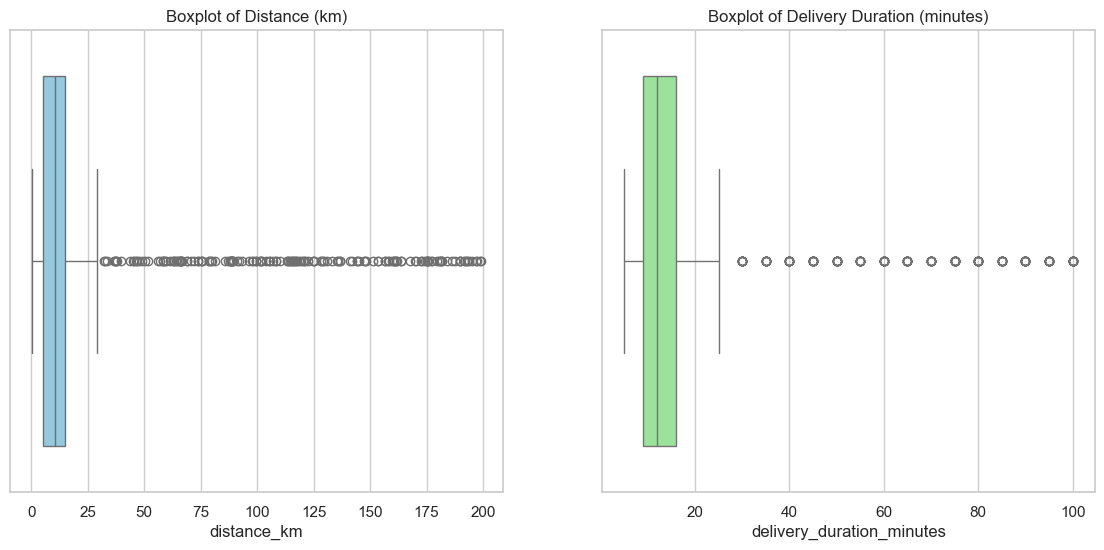

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for distance_km
sns.boxplot(data=df_time, x='distance_km', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance (km)')

# Boxplot for delivery_duration_minutes
sns.boxplot(data=df_time, x='delivery_duration_minutes', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Delivery Duration (minutes)')

plt.show()


In [14]:
# Calculate 1st and 99th percentiles for capping and flooring
lower_percentile = 0.01
upper_percentile = 0.99

for col in ['distance_km', 'delivery_duration_minutes']:
    lower = df_time[col].quantile(lower_percentile)
    upper = df_time[col].quantile(upper_percentile)
    
    # Cap values above the 99th percentile
    df_time[col] = df_time[col].apply(lambda x: upper if x > upper else x)
    
    # Floor values below the 1st percentile (if needed)
    df_time[col] = df_time[col].apply(lambda x: lower if x < lower else x)

# Verify outlier capping
print(df_time[['distance_km', 'delivery_duration_minutes']].describe())


        distance_km  delivery_duration_minutes
count  50000.000000               50000.000000
mean      10.265222                  12.493320
std        5.633695                   4.619409
min        0.690000                   5.000000
25%        5.350000                   9.000000
50%       10.310000                  12.000000
75%       15.140000                  16.000000
max       19.860000                  20.000000


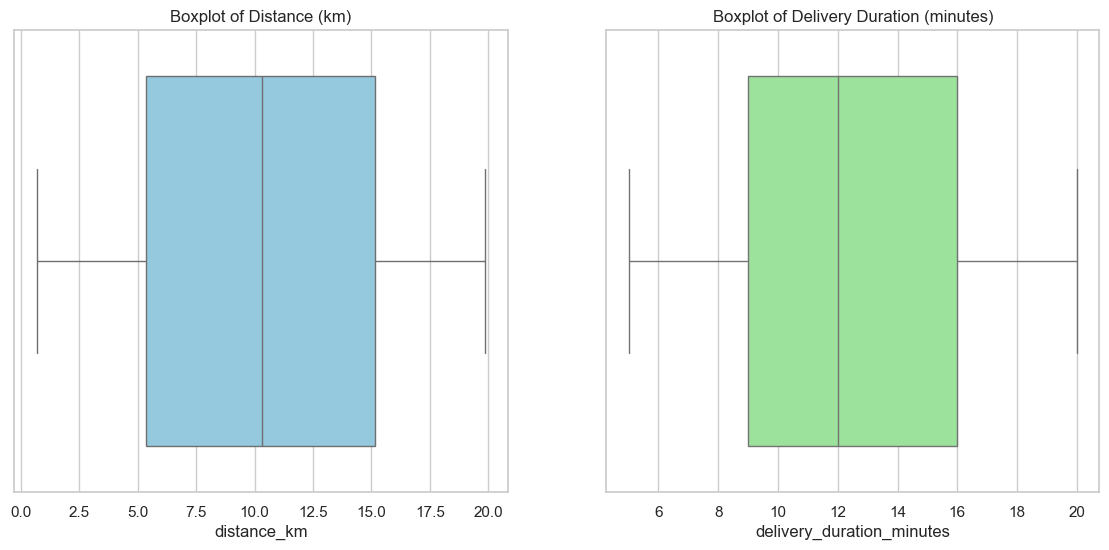

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for distance_km
sns.boxplot(data=df_time, x='distance_km', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance (km)')

# Boxplot for delivery_duration_minutes
sns.boxplot(data=df_time, x='delivery_duration_minutes', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Delivery Duration (minutes)')

plt.show()


In [16]:
# 1. Check for any remaining missing values
missing_counts = df_time.isnull().sum()
print("Missing values count per column:")
print(missing_counts)

# 2. Verify data types for each column
print("\nData types of each column:")
print(df_time.dtypes)

# 3. Check for categorical columns that need encoding
categorical_cols = df_time.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns:")
print(categorical_cols)

# 4. Check for numerical columns
numerical_cols = df_time.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\nNumerical columns:")
print(numerical_cols)

# 5. Check unique values in categorical columns (to understand cardinality)
for col in categorical_cols:
    unique_vals = df_time[col].nunique()
    print(f"Column '{col}' has {unique_vals} unique values")

# 6. Verify no extreme outliers remain in numerical data (using IQR method again)
for col in numerical_cols:
    Q1 = df_time[col].quantile(0.25)
    Q3 = df_time[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_time[(df_time[col] < (Q1 - 1.5 * IQR)) | (df_time[col] > (Q3 + 1.5 * IQR))]
    print(f"Column '{col}' has {outliers.shape[0]} outliers")

# 7. Check for duplicates
duplicates = df_time.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# 8. Basic statistical summary to look for anomalies
print("\nDescriptive statistics summary:")
print(df_time.describe(include='all'))


Missing values count per column:
city                         0
area_of_interest_type        0
distance_km                  0
hour_of_day                  0
day_of_week                  0
is_weekend                   0
delivery_duration_minutes    0
accept_hour                  0
accept_day_of_week           0
accept_month                 0
No_of_orders                 0
traffic                      0
weather_condition            0
traffic_encoded              0
num_delivery_partners        0
population_density           0
dtype: int64

Data types of each column:
city                          object
area_of_interest_type         object
distance_km                  float64
hour_of_day                  float64
day_of_week                   object
is_weekend                   float64
delivery_duration_minutes    float64
accept_hour                  float64
accept_day_of_week            object
accept_month                 float64
No_of_orders                   int64
traffic                

In [17]:
df_time.to_csv('cleaned_dataset.csv', index=False)

In [18]:
df = pd.read_csv("cleaned_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   city                       50000 non-null  object 
 1   area_of_interest_type      50000 non-null  object 
 2   distance_km                50000 non-null  float64
 3   hour_of_day                50000 non-null  float64
 4   day_of_week                50000 non-null  object 
 5   is_weekend                 50000 non-null  float64
 6   delivery_duration_minutes  50000 non-null  float64
 7   accept_hour                50000 non-null  float64
 8   accept_day_of_week         50000 non-null  object 
 9   accept_month               50000 non-null  float64
 10  No_of_orders               50000 non-null  int64  
 11  traffic                    50000 non-null  object 
 12  weather_condition          50000 non-null  object 
 13  traffic_encoded            50000 non-null  int

In [19]:
df.describe()

,distance_km,hour_of_day,is_weekend,delivery_duration_minutes,accept_hour,accept_month,No_of_orders,traffic_encoded,num_delivery_partners,population_density
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,10.265222,11.48594,0.282680,12.493320,11.44382,6.467760,310.726820,1.030060,7.981700,24998.400000
std,5.633695,6.90485,0.450307,4.619409,6.90682,3.439941,132.258631,0.678768,3.739995,11212.783418
min,0.690000,0.00000,0.000000,5.000000,0.00000,1.000000,59.000000,0.000000,2.000000,10000.000000
25%,5.350000,5.00000,0.000000,9.000000,5.00000,3.000000,198.000000,1.000000,5.000000,10000.000000
50%,10.310000,12.00000,0.000000,12.000000,11.00000,6.000000,311.000000,1.000000,8.000000,30000.000000
75%,15.140000,17.00000,1.000000,16.000000,17.00000,9.000000,423.000000,1.000000,11.000000,40000.000000
max,19.860000,23.00000,1.000000,20.000000,23.00000,12.000000,583.000000,2.000000,14.000000,40000.000000


In [20]:
df.shape

(50000, 16)

In [21]:
df.isnull().sum()

city                         0
area_of_interest_type        0
distance_km                  0
hour_of_day                  0
day_of_week                  0
is_weekend                   0
delivery_duration_minutes    0
accept_hour                  0
accept_day_of_week           0
accept_month                 0
No_of_orders                 0
traffic                      0
weather_condition            0
traffic_encoded              0
num_delivery_partners        0
population_density           0
dtype: int64

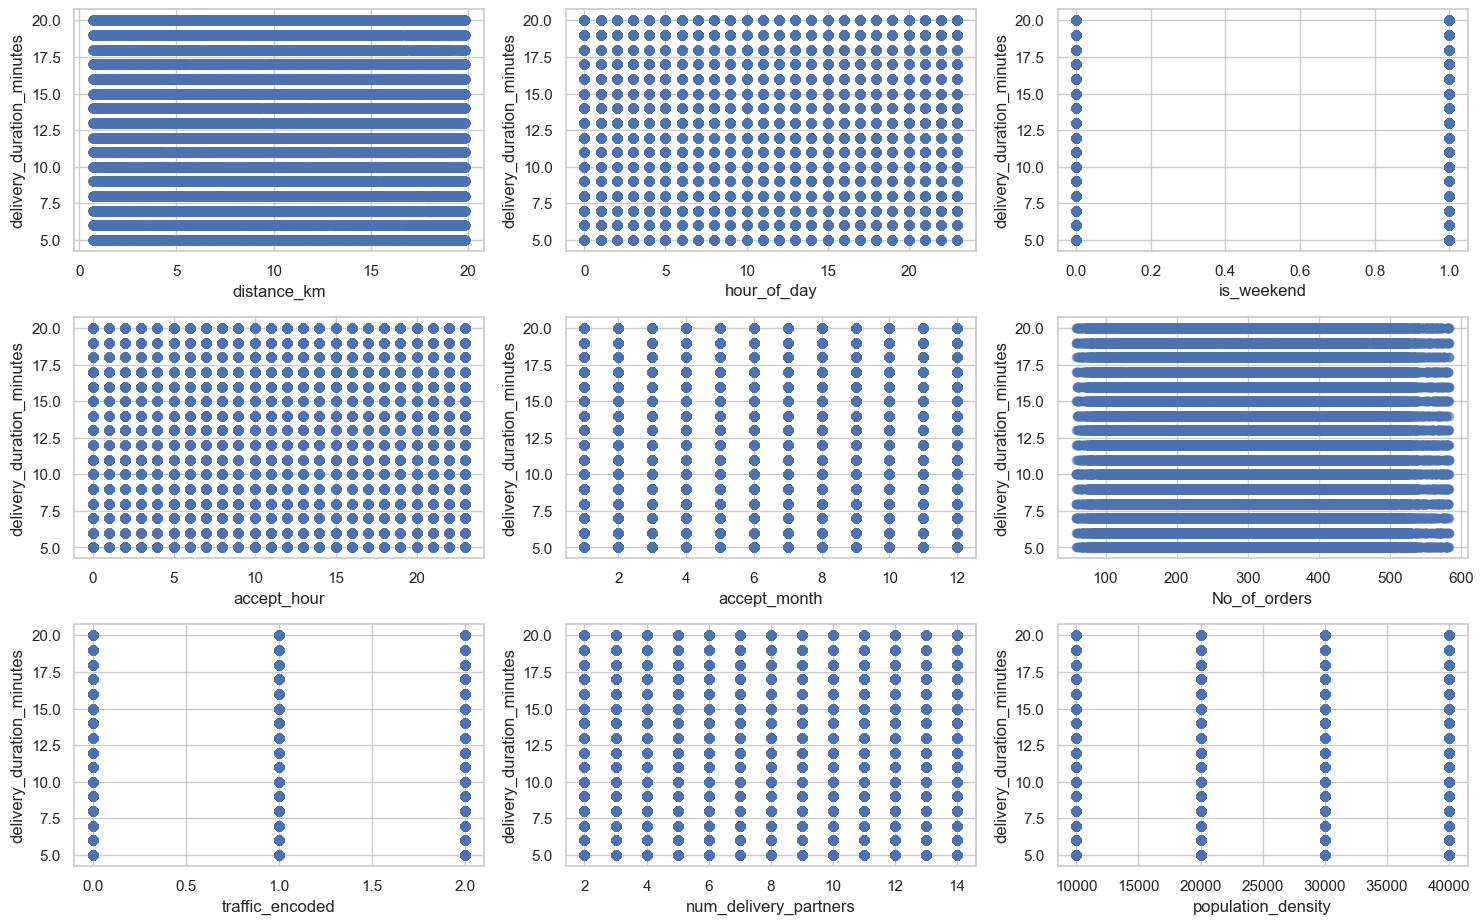

In [22]:
import matplotlib.pyplot as plt

target = 'delivery_duration_minutes'  # Example target variable
num_cols = df_time.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove(target)  # Exclude target from features

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols)//3 + 1, 3, i+1)
    plt.scatter(df_time[col], df_time[target], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()

plt.show()


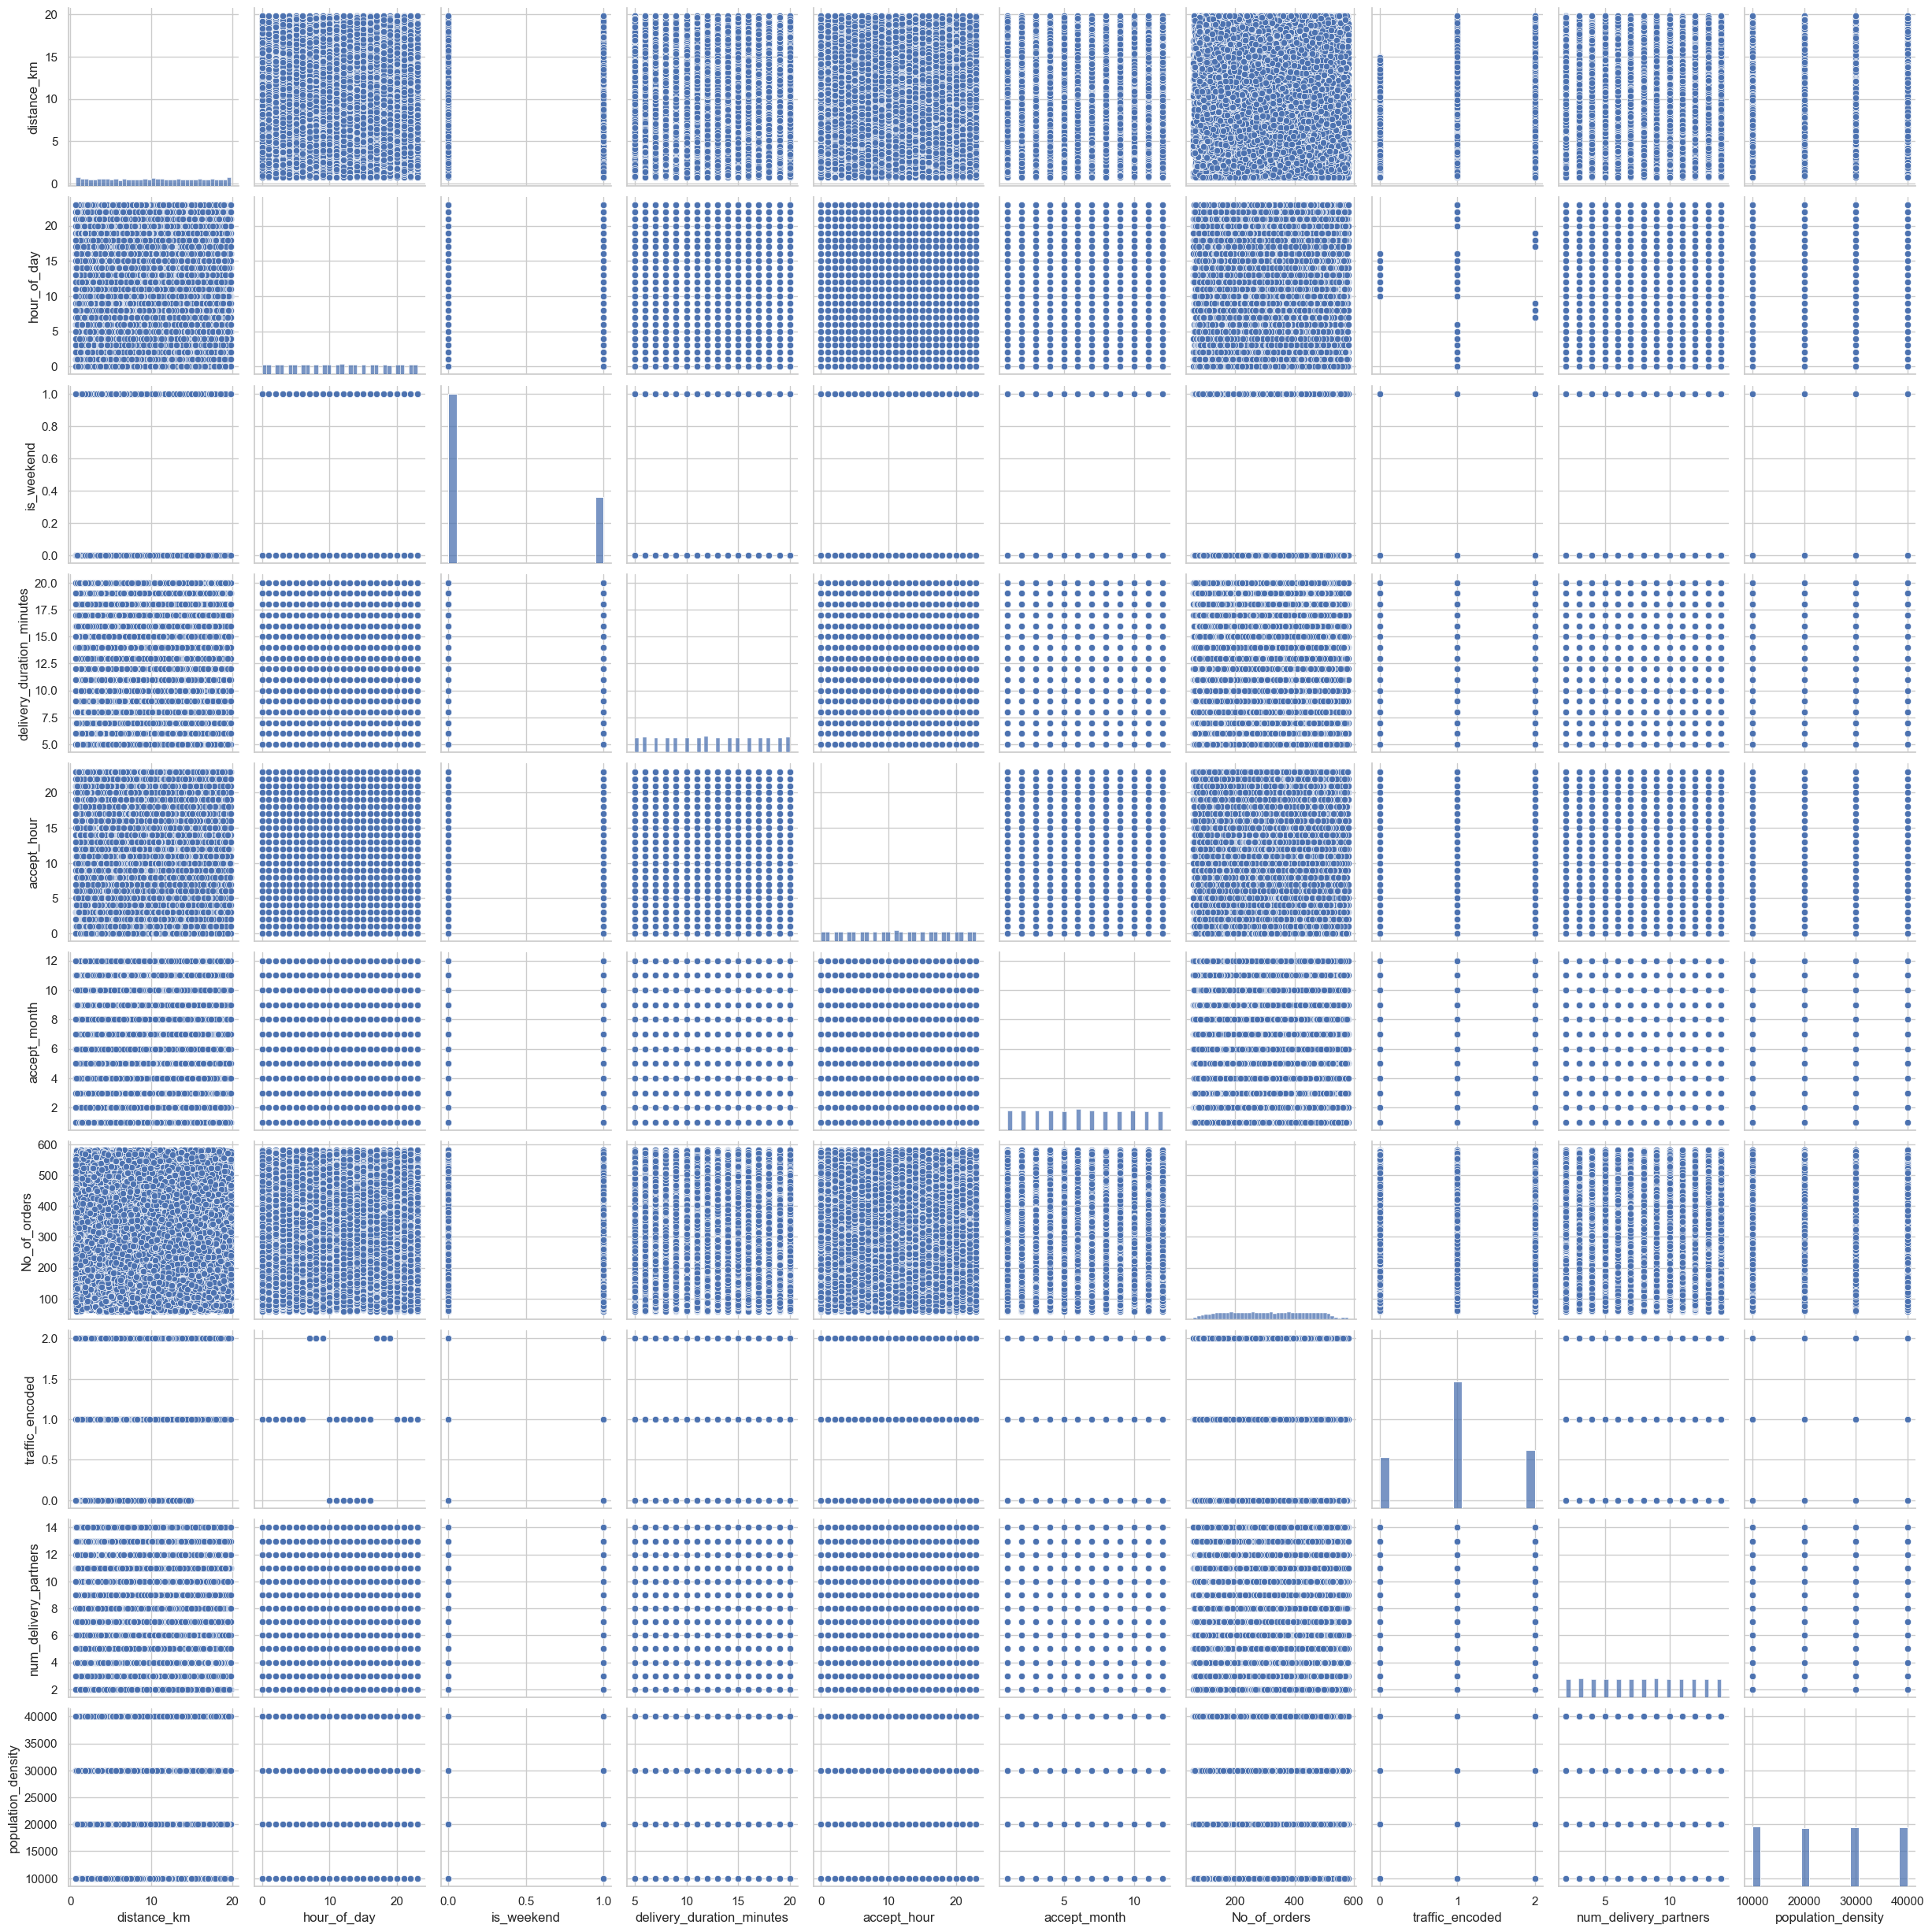

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot for all numeric variables in DataFrame df
sns.pairplot(df)
plt.show()


In [24]:
import pandas as pd

# Assuming df_time is your cleaned DataFrame

# 1. Time-Based Features
# ----------------------
# Rush hour indicator
df_time['is_rush_hour'] = df_time['hour_of_day'].apply(
    lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0
)

# Time of day category
df_time['time_of_day'] = df_time['hour_of_day'].apply(
    lambda x: 'morning'   if 6  <= x < 12 else
              'afternoon' if 12 <= x < 18 else
              'evening'   if 18 <= x < 22 else
              'night'
)

# Weekend × rush hour interaction
df_time['weekend_rush_hour'] = df_time['is_weekend'] * df_time['is_rush_hour']


# 2. Efficiency/Performance Metrics
# ----------------------------------
# Distance per minute (km per delivery minute)
df_time['distance_per_minute'] = (
    df_time['distance_km'] / df_time['delivery_duration_minutes']
)

# Orders per delivery partner
df_time['orders_per_partner'] = (
    df_time['No_of_orders'] / df_time['num_delivery_partners']
)

# Population density per partner
df_time['density_per_partner'] = (
    df_time['population_density'] / df_time['num_delivery_partners']
)


# 3. Interaction Features
# ------------------------
# Weekend × traffic encoded
df_time['weekend_traffic_interaction'] = (
    df_time['is_weekend'] * df_time['traffic_encoded']
)

# Distance × traffic encoded
df_time['distance_traffic_interaction'] = (
    df_time['distance_km'] * df_time['traffic_encoded']
)

# Weather and traffic combined as a new categorical feature
df_time['weather_traffic_combined'] = (
    df_time['weather_condition'] + '_' + df_time['traffic']
)


# 4. Categorical Encoding
# ------------------------
# One-hot encode selected nominal categoricals
nominal_cols = ['city', 'weather_condition']
df_time = pd.get_dummies(
    df_time,
    columns=nominal_cols,
    prefix=['city', 'weather'],
    drop_first=True,
    dtype=int
)

# Ordinal encode days of week
day_order = [
    'Monday', 'Tuesday', 'Wednesday', 
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]
day_map = {day: i for i, day in enumerate(day_order)}
df_time['day_of_week_encoded'] = df_time['day_of_week'].map(day_map)
df_time['accept_day_of_week_encoded'] = df_time['accept_day_of_week'].map(day_map)


# Final check: ensure no missing values introduced
assert df_time.isnull().sum().sum() == 0, "Missing values detected after feature engineering"

# df_time is now ready for modeling


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define target and feature matrix
target = 'delivery_duration_minutes'
features = df_time.drop(columns=[target])
X = features
y = df_time[target]

# 2. Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Feature Scaling on numerical features
num_cols = ['distance_km', 'hour_of_day', 'accept_hour', 
            'accept_month', 'No_of_orders', 'traffic_encoded', 
            'num_delivery_partners', 'population_density', 
            'distance_per_minute', 'orders_per_partner', 
            'density_per_partner', 'distance_traffic_interaction']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Data is now ready for model training


In [26]:
# Check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Check data types
print("\nX_train dtypes:")
print(X_train.dtypes)
print("\ny_train dtype:", y_train.dtype)


X_train shape: (40000, 31)
y_train shape: (40000,)
X_test shape: (10000, 31)
y_test shape: (10000,)

X_train dtypes:
area_of_interest_type            object
distance_km                     float64
hour_of_day                     float64
day_of_week                      object
is_weekend                      float64
accept_hour                     float64
accept_day_of_week               object
accept_month                    float64
No_of_orders                    float64
traffic                          object
traffic_encoded                 float64
num_delivery_partners           float64
population_density              float64
is_rush_hour                      int64
time_of_day                      object
weekend_rush_hour               float64
distance_per_minute             float64
orders_per_partner              float64
density_per_partner             float64
weekend_traffic_interaction     float64
distance_traffic_interaction    float64
weather_traffic_combined         object
cit

In [27]:
# Check for NaN and infinite values first
print("X_train has NaN:", X_train.isnull().any().any())
print("X_train has infinite:", np.isinf(X_train.select_dtypes(include=[np.number])).any().any())
print("y_train has NaN:", y_train.isnull().any())

# Get categorical columns that still need encoding
categorical_cols = ['area_of_interest_type', 'day_of_week', 'traffic', 'accept_day_of_week', 'time_of_day', 'weather_traffic_combined']

# Apply one-hot encoding to remaining categorical columns
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True,dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True,dtype=int)

# Ensure both train and test have same columns
# Get all columns from training set
train_cols = set(X_train_encoded.columns)
test_cols = set(X_test_encoded.columns)

# Add missing columns to test set with 0 values
for col in train_cols - test_cols:
    X_test_encoded[col] = 0

# Add missing columns to train set with 0 values  
for col in test_cols - train_cols:
    X_train_encoded[col] = 0

# Reorder columns to match
X_test_encoded = X_test_encoded[X_train_encoded.columns]

print("After encoding:")
print("X_train shape:", X_train_encoded.shape)
print("X_test shape:", X_test_encoded.shape)


X_train has NaN: False
X_train has infinite: False
y_train has NaN: False
After encoding:
X_train shape: (40000, 52)
X_test shape: (10000, 52)


In [28]:
X_train_encoded

,distance_km,hour_of_day,is_weekend,accept_hour,accept_month,No_of_orders,traffic_encoded,num_delivery_partners,population_density,is_rush_hour,...,time_of_day_morning,time_of_day_night,weather_traffic_combined_Overcast_Low,weather_traffic_combined_Overcast_Medium,weather_traffic_combined_Rain_High,weather_traffic_combined_Rain_Low,weather_traffic_combined_Rain_Medium,weather_traffic_combined_Sunny_High,weather_traffic_combined_Sunny_Low,weather_traffic_combined_Sunny_Medium
39087,-0.444870,-0.364062,1.0,1.089632,0.445701,1.467658,1.428791,1.073485,0.447027,1,...,1,0,0,0,1,0,0,0,0,0
30893,0.692083,1.228716,0.0,-1.517351,-0.135112,-1.399700,-0.043506,1.073485,-0.445510,0,...,0,0,0,1,0,0,0,0,0,0
45278,1.141535,0.504726,0.0,-0.938022,0.155295,0.915370,-0.043506,0.272083,-0.445510,0,...,0,0,0,1,0,0,0,0,0,0
16398,0.258620,0.939120,0.0,1.379297,-1.006331,-1.119773,1.428791,0.806351,1.339565,1,...,0,0,0,0,0,0,0,0,0,0
13653,-1.196325,-0.508860,1.0,-0.938022,0.445701,0.930501,1.428791,0.539217,1.339565,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,1.102452,-0.508860,1.0,-0.648357,-1.587144,-1.127339,1.428791,1.340619,-0.445510,1,...,1,0,0,0,1,0,0,0,0,0
44732,-1.206984,-1.232850,0.0,-1.517351,-1.296738,1.021288,-0.043506,1.607753,1.339565,0,...,0,1,0,1,0,0,0,0,0,0
38158,-0.123325,-0.074466,0.0,0.944800,-1.006331,-0.181640,-1.515804,0.806351,0.447027,0,...,1,0,0,0,0,1,0,0,0,0
860,0.988757,1.083918,0.0,1.234465,-0.425518,0.469000,1.428791,-0.262185,-1.338047,1,...,0,0,0,0,1,0,0,0,0,0


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 3. Train the model with encoded data
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_encoded, y_train)

# 4. Make predictions
y_pred = rf.predict(X_test_encoded)

# # 5. Evaluate performance
# mae = mean_absolute_error(y_test, y_pred)
# rmse = mean_squared_error(y_test, y_pred, squared=False)
# r2 = r2_score(y_test, y_pred)

# print(f"Mean Absolute Error (MAE): {mae:.2f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
# print(f"R² Score: {r2:.3f}")


In [31]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Fit to training data
random_search.fit(X_train_encoded, y_train)

# Best parameters and score
print("Best R² score:", random_search.best_score_)
print("Best parameters:", random_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best R² score: 0.7417609881434787
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [32]:
best_rf = random_search.best_estimator_

# Evaluate on test set
y_pred_best = best_rf.predict(X_test_encoded)
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_best))
# print("Tuned RMSE:", mean_squared_error(y_test, y_pred_best, squared=False))
print("Tuned R²:", r2_score(y_test, y_pred_best))


Tuned MAE: 1.7033728195371787
Tuned R²: 0.7623509220006666


In [33]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf, X_train_encoded, y_train, 
    cv=5, scoring='r2', n_jobs=-1
)
print("5-fold CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean(), "±", cv_scores.std()*2)

5-fold CV R² scores: [0.74527408 0.75773059 0.75053448 0.74778605 0.75748183]
Mean CV R²: 0.7517614069679294 ± 0.010109348534716516


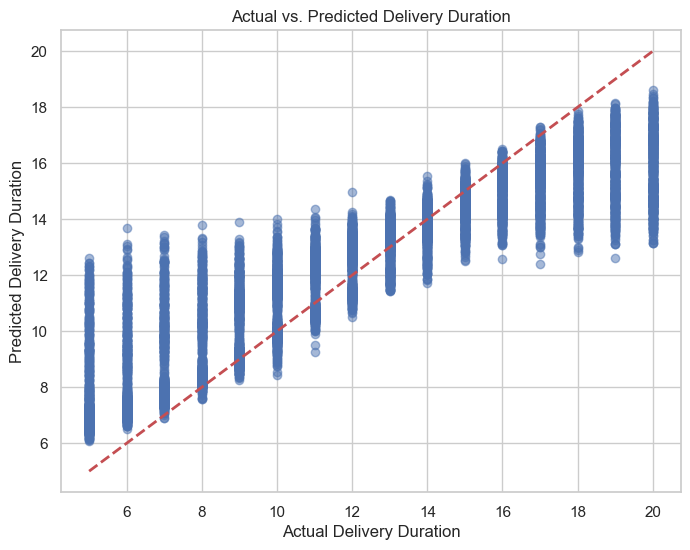

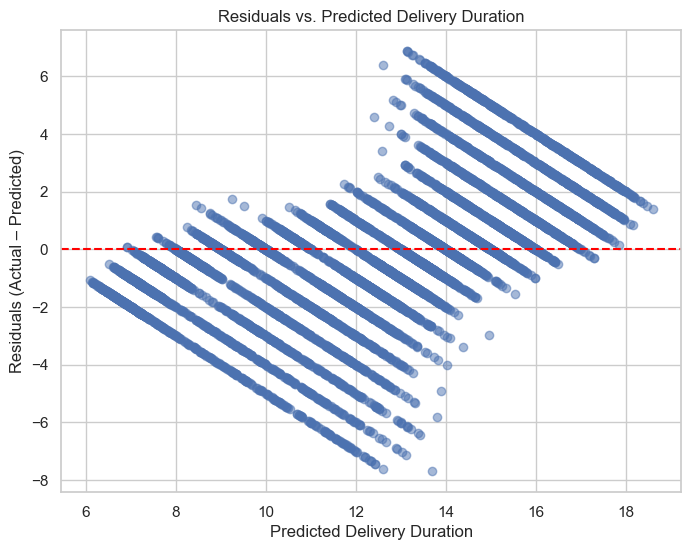

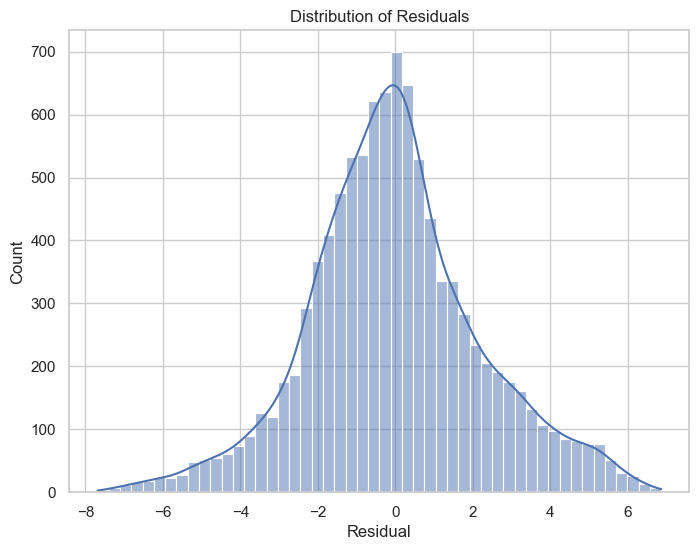

Top 10 Most Important Features:
                         feature  importance
11           distance_per_minute    0.474573
0                    distance_km    0.116047
15  distance_traffic_interaction    0.070306
12            orders_per_partner    0.034301
5                   No_of_orders    0.033753
3                    accept_hour    0.026586
13           density_per_partner    0.024517
4                   accept_month    0.021498
1                    hour_of_day    0.020202
7          num_delivery_partners    0.019659


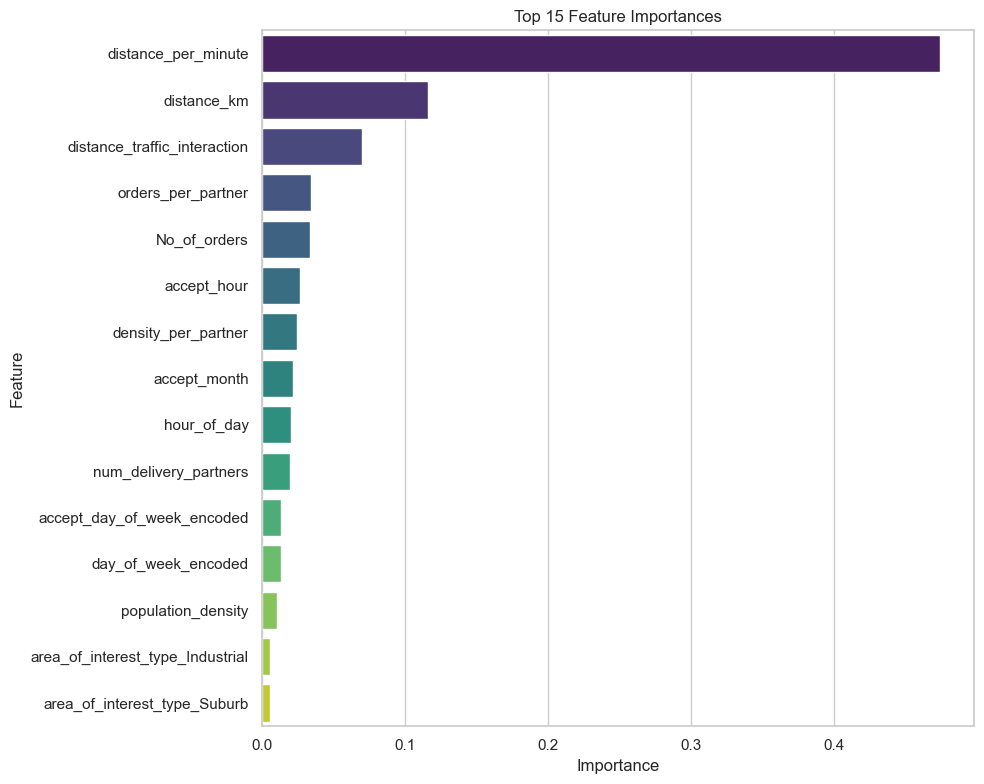

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Residual Analysis
# --------------------

# Predict on test set
y_pred = best_rf.predict(X_test_encoded)

# Compute residuals
residuals = y_test - y_pred

# Plot 1: Predicted vs. Actual delivery duration
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Delivery Duration')
plt.ylabel('Predicted Delivery Duration')
plt.title('Actual vs. Predicted Delivery Duration')
plt.show()

# Plot 2: Residuals vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Delivery Duration')
plt.ylabel('Residuals (Actual – Predicted)')
plt.title('Residuals vs. Predicted Delivery Duration')
plt.show()

# Plot 3: Residual distribution
plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.xlabel('Residual')
plt.title('Distribution of Residuals')
plt.show()


# 2. Feature Importance Review
# ----------------------------

# Extract feature importances
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Display top 10 features
print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Plot top 15 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(15),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [35]:
X_train_encoded.head(1).T

,39087
distance_km,-0.444870
hour_of_day,-0.364062
is_weekend,1.000000
accept_hour,1.089632
accept_month,0.445701
No_of_orders,1.467658
traffic_encoded,1.428791
num_delivery_partners,1.073485
population_density,0.447027
is_rush_hour,1.000000


In [36]:
X_train_encoded.columns

Index(['distance_km', 'hour_of_day', 'is_weekend', 'accept_hour',
       'accept_month', 'No_of_orders', 'traffic_encoded',
       'num_delivery_partners', 'population_density', 'is_rush_hour',
       'weekend_rush_hour', 'distance_per_minute', 'orders_per_partner',
       'density_per_partner', 'weekend_traffic_interaction',
       'distance_traffic_interaction', 'city_Houston', 'city_Los Angeles',
       'city_New York', 'city_San Francisco', 'city_Unknown', 'weather_Rain',
       'weather_Sunny', 'day_of_week_encoded', 'accept_day_of_week_encoded',
       'area_of_interest_type_Industrial', 'area_of_interest_type_Suburb',
       'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday',
       'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday',
       'traffic_Low', 'traffic_Medium', 'accept_day_of_week_Monday',
       'accept_day_of_week_Saturday', 'accept_day_of_week_Sunday',
       'accept_day_of_week_Thursday', 'accept_day_of_week_Tuesday',
       'a

In [37]:
test_array = X_train_encoded.head(1).values
test_array

array([[-0.44486975, -0.36406209,  1.        ,  1.08963225,  0.44570136,
         1.46765822,  1.42879139,  1.07348498,  0.44702729,  1.        ,
         1.        , -0.62196117, -0.2569709 , -0.48248527,  2.        ,
         0.45162151,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  5.        ,  2.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ]])

In [42]:
rf.predict(test_array)

array([15.])

In [45]:
df['area_of_interest_type'].value_counts()

area_of_interest_type
Downtown      16968
Suburb        16599
Industrial    16433
Name: count, dtype: int64

In [47]:
project_data = {
    # --- categorical mappings ---
    'city': {
        "Houston": 0,
        "Los Angeles": 1,
        "New York": 2,
        "San Francisco": 3,
        "Unknown": 4
    },
    'weather': {
        "Rain": 0,
        "Sunny": 1
    },
    'area_of_interest_type': {
        "Industrial": 0,
        "Suburb": 1
    },
    'day_of_week': {
        "Monday": 0,
        "Tuesday": 1,
        "Wednesday": 2,
        "Thursday": 3,
        "Saturday": 4,
        "Sunday": 5
    },
    'accept_day_of_week': {
        "Monday": 0,
        "Tuesday": 1,
        "Wednesday": 2,
        "Thursday": 3,
        "Saturday": 4,
        "Sunday": 5
    },
    'traffic': {
        "Low": 0,
        "Medium": 1
    },
    'time_of_day': {
        "morning": 0,
        "evening": 1,
        "night": 2
    },
    'weather_traffic_combined': {
        "Overcast_Low": 0,
        "Overcast_Medium": 1,
        "Rain_High": 2,
        "Rain_Low": 3,
        "Rain_Medium": 4,
        "Sunny_High": 5,
        "Sunny_Low": 6,
        "Sunny_Medium": 7
    },

    # --- all columns in correct order ---
    'columns': [
        'distance_km', 'hour_of_day', 'is_weekend', 'accept_hour',
        'accept_month', 'No_of_orders', 'traffic_encoded',
        'num_delivery_partners', 'population_density', 'is_rush_hour',
        'weekend_rush_hour', 'distance_per_minute', 'orders_per_partner',
        'density_per_partner', 'weekend_traffic_interaction',
        'distance_traffic_interaction', 'city_Houston',
        'city_Los Angeles', 'city_New York', 'city_San Francisco',
        'city_Unknown', 'weather_Rain', 'weather_Sunny',
        'day_of_week_encoded', 'accept_day_of_week_encoded',
        'area_of_interest_type_Industrial', 'area_of_interest_type_Suburb',
        'day_of_week_Monday', 'day_of_week_Saturday',
        'day_of_week_Sunday', 'day_of_week_Thursday',
        'day_of_week_Tuesday', 'day_of_week_Wednesday',
        'traffic_Low', 'traffic_Medium', 'accept_day_of_week_Monday',
        'accept_day_of_week_Saturday', 'accept_day_of_week_Sunday',
        'accept_day_of_week_Thursday', 'accept_day_of_week_Tuesday',
        'accept_day_of_week_Wednesday', 'time_of_day_evening',
        'time_of_day_morning', 'time_of_day_night',
        'weather_traffic_combined_Overcast_Low',
        'weather_traffic_combined_Overcast_Medium',
        'weather_traffic_combined_Rain_High',
        'weather_traffic_combined_Rain_Low',
        'weather_traffic_combined_Rain_Medium',
        'weather_traffic_combined_Sunny_High',
        'weather_traffic_combined_Sunny_Low',
        'weather_traffic_combined_Sunny_Medium'
    ]
}

print(project_data)


{'city': {'Houston': 0, 'Los Angeles': 1, 'New York': 2, 'San Francisco': 3, 'Unknown': 4}, 'weather': {'Rain': 0, 'Sunny': 1}, 'area_of_interest_type': {'Industrial': 0, 'Suburb': 1}, 'day_of_week': {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Saturday': 4, 'Sunday': 5}, 'accept_day_of_week': {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Saturday': 4, 'Sunday': 5}, 'traffic': {'Low': 0, 'Medium': 1}, 'time_of_day': {'morning': 0, 'evening': 1, 'night': 2}, 'weather_traffic_combined': {'Overcast_Low': 0, 'Overcast_Medium': 1, 'Rain_High': 2, 'Rain_Low': 3, 'Rain_Medium': 4, 'Sunny_High': 5, 'Sunny_Low': 6, 'Sunny_Medium': 7}, 'columns': ['distance_km', 'hour_of_day', 'is_weekend', 'accept_hour', 'accept_month', 'No_of_orders', 'traffic_encoded', 'num_delivery_partners', 'population_density', 'is_rush_hour', 'weekend_rush_hour', 'distance_per_minute', 'orders_per_partner', 'density_per_partner', 'weekend_traffic_interaction', 'distance_traffic_interaction', 

In [49]:
# Example input values (replace with real inputs from your app/user)
distance_km = 5.4
hour_of_day = 14
is_weekend = 0
accept_hour = 15
accept_month = 9
No_of_orders = 120
traffic_encoded = 1
num_delivery_partners = 8
population_density = 4500
is_rush_hour = 1
weekend_rush_hour = 0
distance_per_minute = 0.12
orders_per_partner = 15
density_per_partner = 560
weekend_traffic_interaction = 0
distance_traffic_interaction = 1

# categorical inputs
City = "New York"
Weather = "Sunny"
DayOfWeek = "Monday"
AcceptDayOfWeek = "Tuesday"
AreaOfInterest = "Suburb"
Traffic = "Low"
TimeOfDay = "evening"
WeatherTraffic = "Sunny_High"


In [50]:
import numpy as np

# Create an empty array of zeros for all features
test_array = np.zeros(len(project_data['columns']))

# --- Assign continuous / numeric features ---
test_array[0]  = distance_km
test_array[1]  = hour_of_day
test_array[2]  = is_weekend
test_array[3]  = accept_hour
test_array[4]  = accept_month
test_array[5]  = No_of_orders
test_array[6]  = traffic_encoded
test_array[7]  = num_delivery_partners
test_array[8]  = population_density
test_array[9]  = is_rush_hour
test_array[10] = weekend_rush_hour
test_array[11] = distance_per_minute
test_array[12] = orders_per_partner
test_array[13] = density_per_partner
test_array[14] = weekend_traffic_interaction
test_array[15] = distance_traffic_interaction

# --- Handle categorical one-hot encoded variables ---
# Example: city
city_name = "city_" + City   # e.g., "city_New York"
city_index = project_data['columns'].index(city_name)
test_array[city_index] = 1

# Example: weather
weather_name = "weather_" + Weather   # e.g., "weather_Sunny"
weather_index = project_data['columns'].index(weather_name)
test_array[weather_index] = 1

# Example: day_of_week
dow_name = "day_of_week_" + DayOfWeek   # e.g., "day_of_week_Monday"
dow_index = project_data['columns'].index(dow_name)
test_array[dow_index] = 1

# Example: accept_day_of_week
accept_dow_name = "accept_day_of_week_" + AcceptDayOfWeek
accept_dow_index = project_data['columns'].index(accept_dow_name)
test_array[accept_dow_index] = 1

# Example: area_of_interest_type
aoi_name = "area_of_interest_type_" + AreaOfInterest   # e.g., "Suburb"
aoi_index = project_data['columns'].index(aoi_name)
test_array[aoi_index] = 1

# Example: traffic
traffic_name = "traffic_" + Traffic   # e.g., "traffic_Low"
traffic_index = project_data['columns'].index(traffic_name)
test_array[traffic_index] = 1

# Example: time_of_day
tod_name = "time_of_day_" + TimeOfDay   # e.g., "time_of_day_evening"
tod_index = project_data['columns'].index(tod_name)
test_array[tod_index] = 1

# Example: weather_traffic_combined
wtc_name = "weather_traffic_combined_" + WeatherTraffic   # e.g., "Rain_High"
wtc_index = project_data['columns'].index(wtc_name)
test_array[wtc_index] = 1

# View the test array
np.set_printoptions(suppress=True)
print(test_array)


[   5.4    14.      0.     15.      9.    120.      1.      8.   4500.
    1.      0.      0.12   15.    560.      0.      1.      0.      0.
    1.      0.      0.      0.      1.      0.      0.      0.      1.
    1.      0.      0.      0.      0.      0.      1.      0.      0.
    0.      0.      0.      1.      0.      1.      0.      0.      0.
    0.      0.      0.      0.      1.      0.      0.  ]


In [52]:
np.set_printoptions(suppress=True)
print(test_array)

[   5.4    14.      0.     15.      9.    120.      1.      8.   4500.
    1.      0.      0.12   15.    560.      0.      1.      0.      0.
    1.      0.      0.      0.      1.      0.      0.      0.      1.
    1.      0.      0.      0.      0.      0.      1.      0.      0.
    0.      0.      0.      1.      0.      1.      0.      0.      0.
    0.      0.      0.      0.      1.      0.      0.  ]


In [59]:
result = rf.predict([test_array])[0]
print(f'Predicted Estimated Delivery Time: {round(result,2) } minutes')

Predicted Estimated Delivery Time: 18.04 minutes


In [61]:
import pickle

with open('Linear_Model.pkl', 'wb') as f:
    pickle.dump(rf, f)

In [63]:
import json

with open('project_data.json', 'w') as f:
    json.dump(project_data, f)